In [1]:
import re
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

c:\SKRIPSI BRYAN\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


Preprocessing...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 866.93it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 Training IndoBERT (Monitor Recall)...


100%|██████████| 578/578 [02:06<00:00,  4.55it/s]



Epoch 1
Train Loss: 0.1692
Val Recall: 0.8030
✅ Model terbaik diperbarui (Recall naik)


...


Epoch 4
Train Loss: 0.0221
Val Recall: 0.8485


100%|██████████| 578/578 [02:08<00:00,  4.51it/s]



Epoch 5
Train Loss: 0.0129
Val Recall: 0.8485
🛑 Early stopping triggered


100%|██████████| 221/221 [00:14<00:00, 15.45it/s]



=== FINAL TEST EVALUATION ===
Accuracy : 0.9279023559466364
Precision: 0.8943396226415095
Recall   : 0.7053571428571429
F1-score : 0.7886855241264559
AUC      : 0.9180313194200864

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0     0.9338    0.9804    0.9565      2851
           1     0.8943    0.7054    0.7887       672

    accuracy                         0.9279      3523
   macro avg     0.9141    0.8429    0.8726      3523
weighted avg     0.9263    0.9279    0.9245      3523

=== CONFUSION MATRIX ===
[[2795   56]
 [ 198  474]]


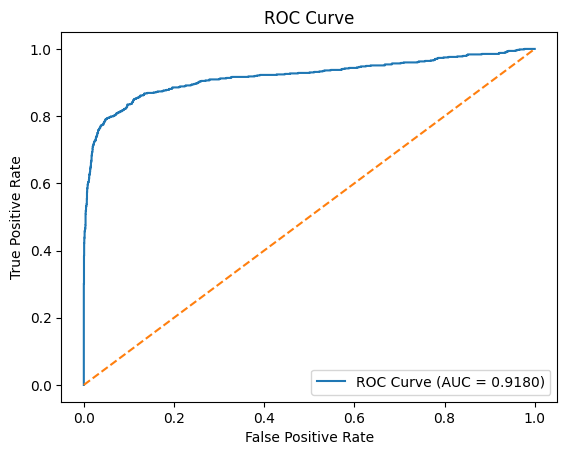

In [2]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = html.unescape(text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

train_df = pd.read_csv(r"C:\SKRIPSI BRYAN\Tahap 2\2B\mlm_70_100.csv")
val_df   = pd.read_csv(r'C:\SKRIPSI BRYAN\Tahap 2\2B\data_10_2B.csv')
test_df  = pd.read_csv(r"C:\SKRIPSI BRYAN\Tahap 2\2B\data_20_ovr.csv")

X_train_text = train_df["Text"]
y_train      = train_df["label"]

X_val_text   = val_df["Text"]
y_val        = val_df["label"]

X_test_text  = test_df["Text"]
y_test       = test_df["label"]

print("Preprocessing...")
X_train_text = [preprocess_text(t) for t in tqdm(X_train_text)]
X_val_text   = [preprocess_text(t) for t in tqdm(X_val_text)]
X_test_text  = [preprocess_text(t) for t in tqdm(X_test_text)]

model_name = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=1
)

model.to(device)

class IndoBERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels.values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float)
        }

train_loader = DataLoader(
    IndoBERTDataset(X_train_text, y_train, tokenizer),
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    IndoBERTDataset(X_val_text, y_val, tokenizer),
    batch_size=16
)

test_loader = DataLoader(
    IndoBERTDataset(X_test_text, y_test, tokenizer),
    batch_size=16
)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
criterion = nn.BCEWithLogitsLoss()

epochs = 20
patience = 3
best_val_recall = 0
counter = 0
best_model_state = None

total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print("🚀 Training IndoBERT (Monitor Recall)...")

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits.view(-1)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    # ===== VALIDATION =====
    model.eval()
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            probs = torch.sigmoid(outputs.logits.view(-1))
            preds = (probs >= 0.5).float()

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_recall = recall_score(val_labels, val_preds)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {total_loss/len(train_loader):.4f}")
    print(f"Val Recall: {val_recall:.4f}")

    if val_recall > best_val_recall:
        best_val_recall = val_recall
        counter = 0
        best_model_state = model.state_dict()
        print("✅ Model terbaik diperbarui (Recall naik)")
    else:
        counter += 1
        if counter >= patience:
            print("🛑 Early stopping triggered")
            break

model.load_state_dict(best_model_state)
model.eval()

all_preds = []
all_probs = []

with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = torch.sigmoid(outputs.logits.view(-1))
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend((probs >= 0.5).cpu().numpy())

y_pred = np.array(all_preds)
y_proba = np.array(all_probs)

print("\n=== FINAL TEST EVALUATION ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("AUC      :", roc_auc_score(y_test, y_proba))

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, digits=4))

print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Hitung ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # garis random classifier

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.show()